API 키 업로드

In [1]:
# 1. 파일 업로드 창 띄우기 (실행 후 '파일 선택' 버튼을 눌러 PC의 kaggle.json 업로드)
from google.colab import files
files.upload()

# 2. kaggle.json 파일을 숨김 폴더(~/.kaggle)로 이동하고 읽기 권한(600) 부여
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API 세팅 완료!")

Saving kaggle.json to kaggle.json
Kaggle API 세팅 완료!


데이터셋 다운로드 및 압축 풀기

In [2]:
# 1. 데이터셋 다운로드 (약 3GB, 보통 1~2분 내외 소요)
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

# 2. 다운로드한 압축 파일 풀기
# (-q 옵션으로 수만 줄의 압축 해제 로그를 숨기고, skin_cancer_data 폴더에 풉니다)
!unzip -q skin-cancer-mnist-ham10000.zip -d skin_cancer_data/

print("데이터 다운로드 및 압축 해제 완료!")

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [02:10<00:00, 42.8MB/s]

데이터 다운로드 및 압축 해제 완료!


로컬 데이터 로더 세팅하기

In [3]:
import os
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torch
from collections import Counter

# 1. 메타데이터(CSV) 불러오기 및 이미지 경로 매핑
base_dir = 'skin_cancer_data'
csv_path = os.path.join(base_dir, 'HAM10000_metadata.csv')
df = pd.read_csv(csv_path)

# 이미지가 여러 폴더에 나뉘어 있을 수 있으므로, 전체 경로를 찾아 딕셔너리로 만듭니다.
imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x
                     for dirpath, _, filenames in os.walk(base_dir)
                     for x in [os.path.join(dirpath, f) for f in filenames]
                     if x.endswith('.jpg')}

# 데이터프레임에 실제 이미지 파일 경로 컬럼 추가
df['path'] = df['image_id'].map(imageid_path_dict)

# 2. 이진 분류 라벨링 (Malignant: 1, Benign: 0)
# HAM10000의 악성(Malignant) 클래스: mel(흑색종), bcc(기저세포암), akiec(광선각화증)
malignant_classes = ['mel', 'bcc', 'akiec']
df['label'] = df['dx'].apply(lambda x: 1 if x in malignant_classes else 0)

# 3. Train / Val / Test 데이터 분할 (8 : 1 : 1 비율)
# stratify=df['label']을 통해 양성/악성 비율이 고르게 분배되도록 합니다.
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"데이터 분할 완료 -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# 4. 로컬 파일 읽기용 커스텀 Dataset 클래스
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 로컬 경로에서 이미지를 열어 RGB로 변환
        img_path = self.df.loc[idx, 'path']
        image = Image.open(img_path).convert('RGB')
        label = self.df.loc[idx, 'label']

        if self.transform:
            image = self.transform(image)

        return image, label

# 5. Transform 적용 (ResNet-50 입력 크기 224x224 적용)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 6. Dataset 인스턴스 생성
train_ds = HAM10000Dataset(train_df, transform=train_transform)
val_ds = HAM10000Dataset(val_df, transform=val_transform)
test_ds = HAM10000Dataset(test_df, transform=val_transform)

# 7. 클래스 불균형 해소를 위한 WeightedRandomSampler (이전 코드의 장점 유지) [cite: 114]
label_counts = Counter(train_df['label'])
print(f"⚖️ Train 데이터 분포 -> Benign(0): {label_counts[0]}, Malignant(1): {label_counts[1]}")

weights = [1.0 / label_counts[lbl] for lbl in train_df['label']]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

# 8. DataLoader 생성
train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

print("로컬 데이터 로더(DataLoader) 세팅 완벽하게 끝났습니다!")

데이터 분할 완료 -> Train: 8012 | Val: 1001 | Test: 1002
⚖️ Train 데이터 분포 -> Benign(0): 6449, Malignant(1): 1563
로컬 데이터 로더(DataLoader) 세팅 완벽하게 끝났습니다!


모델 설계 및 훈련

In [4]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch

# 1. Device 설정 확인 (이전 셀에서 설정했지만 안전을 위해 다시 확인)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. 전이 학습 모델 설계 (ResNet-50)
import torchvision.models as models

print("🧠 ResNet-50 모델을 불러오는 중...")
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 마지막 출력층(Fully Connected Layer)을 이진 분류용(출력 노드 1개)으로 변경
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 1)
model = model.to(device)

# 3. 손실 함수 및 옵티마이저 세팅
# 샘플러에서 불균형을 처리했으므로 pos_weight는 사용하지 않습니다.
criterion = nn.BCEWithLogitsLoss()

# 전이 학습이므로 기존 가중치가 무너지지 않게 학습률은 1e-4로 낮게 설정합니다.
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# 4. 학습(Train) 및 검증(Evaluate) 함수 정의
def train_one_epoch(loader):
    model.train()
    total_loss, correct = 0.0, 0
    for imgs, labels in tqdm(loader, leave=False, desc="Training"):
        imgs, labels = imgs.to(device), labels.float().to(device)
        optimizer.zero_grad()

        # 차원 불일치 방지를 위해 squeeze(1) 적용
        outputs = model(imgs).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (preds == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

def evaluate(loader, desc="Evaluating"):
    model.eval()
    total_loss, correct = 0.0, 0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, leave=False, desc=desc):
            imgs, labels = imgs.to(device), labels.float().to(device)
            outputs = model(imgs).squeeze(1)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()
            correct += (preds == labels).sum().item()

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / len(loader.dataset), correct / len(loader.dataset), auc

# 5. 본격적인 모델 학습 루프
EPOCHS = 10  # 로컬 데이터이므로 학습 속도가 빠릅니다. 먼저 10 Epoch만 돌려봅니다.
best_auc = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_auc': []}

print("\n🚀 본격적인 학습을 시작합니다!")
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(train_loader)
    va_loss, va_acc, va_auc = evaluate(val_loader)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)
    history['val_auc'].append(va_auc)

    # Validation AUC가 개선될 때마다 모델 가중치 저장
    if va_auc > best_auc:
        best_auc = va_auc
        torch.save(model.state_dict(), 'best_resnet50_ham10000.pth')

    print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {va_loss:.4f} Acc: {va_acc:.4f} AUC: {va_auc:.4f}")

print(f'\n 최고 AUC: {best_auc:.4f}')

🧠 ResNet-50 모델을 불러오는 중...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 132MB/s]



🚀 본격적인 학습을 시작합니다!


Epoch [01/10] | Train Loss: 0.3937 Acc: 0.8205 | Val Loss: 0.2898 Acc: 0.8731 AUC: 0.9272


Epoch [02/10] | Train Loss: 0.3017 Acc: 0.8679 | Val Loss: 0.3027 Acc: 0.8661 AUC: 0.9444


...

Epoch [06/10] | Train Loss: 0.1394 Acc: 0.9504 | Val Loss: 0.2539 Acc: 0.9091 AUC: 0.9562


Epoch [07/10] | Train Loss: 0.1136 Acc: 0.9598 | Val Loss: 0.2407 Acc: 0.9151 AUC: 0.9565


Epoch [08/10] | Train Loss: 0.0971 Acc: 0.9657 | Val Loss: 0.2586 Acc: 0.9031 AUC: 0.9573


Epoch [09/10] | Train Loss: 0.0876 Acc: 0.9685 | Val Loss: 0.2637 Acc: 0.9141 AUC: 0.9546


Epoch [10/10] | Train Loss: 0.0795 Acc: 0.9689 | Val Loss: 0.2706 Acc: 0.9111 AUC: 0.9536

 최고 AUC: 0.9573


시각화

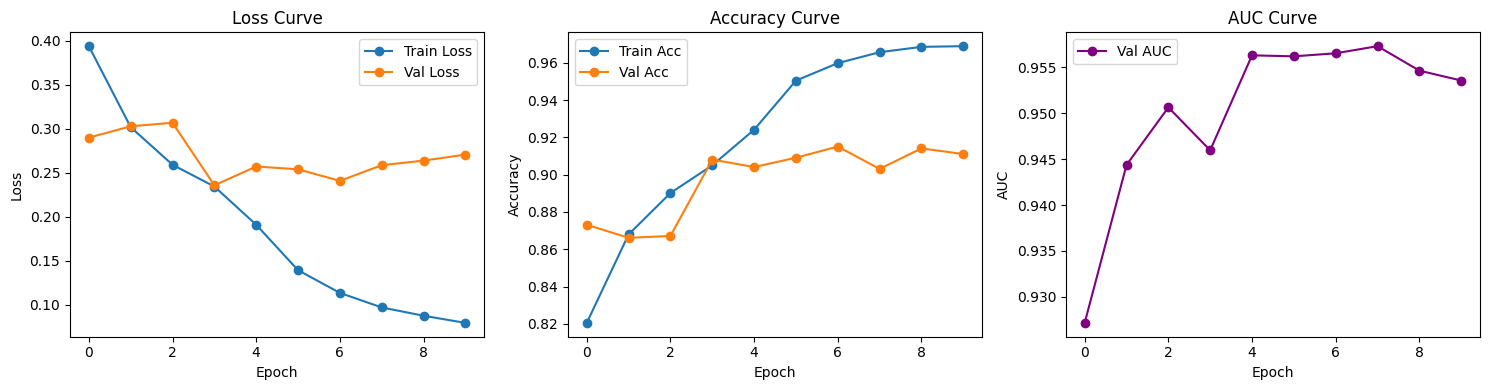


🔍 Test 데이터셋으로 최종 평가를 진행합니다...


✅ 최종 Test Accuracy: 0.8952 | Test AUC: 0.9520


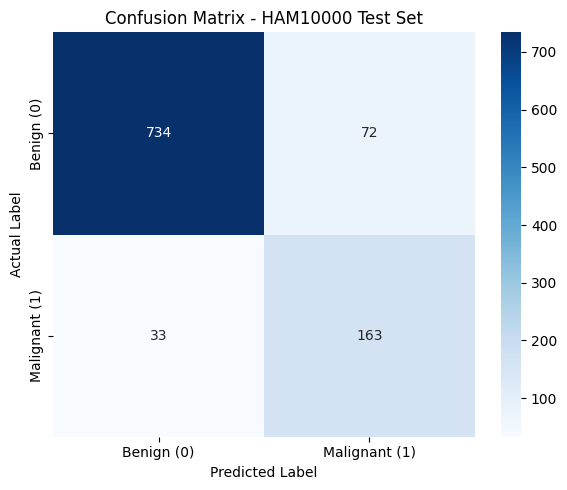


📊 상세 분류 리포트:
                precision    recall  f1-score   support

   Benign (양성)       0.96      0.91      0.93       806
Malignant (악성)       0.69      0.83      0.76       196

      accuracy                           0.90      1002
     macro avg       0.83      0.87      0.84      1002
  weighted avg       0.91      0.90      0.90      1002



In [5]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. 학습 곡선 (Learning Curve) 시각화
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Loss 그래프
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='o')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy 그래프
ax2.plot(history['train_acc'], label='Train Acc', marker='o')
ax2.plot(history['val_acc'], label='Val Acc', marker='o')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

# AUC 그래프
ax3.plot(history['val_auc'], label='Val AUC', color='purple', marker='o')
ax3.set_title('AUC Curve')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('AUC')
ax3.legend()

plt.tight_layout()
plt.show()

# 2. 테스트 데이터 최종 평가
print("\n🔍 Test 데이터셋으로 최종 평가를 진행합니다...")

# 저장해둔 최고 성능의 모델 가중치 불러오기
model.load_state_dict(torch.load('best_resnet50_ham10000.pth'))
model.to(device)

# 앞서 정의한 evaluate 함수 사용
test_loss, test_acc, test_auc = evaluate(test_loader, desc="Testing")
print(f"✅ 최종 Test Accuracy: {test_acc:.4f} | Test AUC: {test_auc:.4f}")

# 3. 예측 결과 추출 (혼동 행렬용)
all_preds = []
all_labels_list = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs).squeeze(1)
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float().cpu()

        all_preds.extend(preds.numpy())
        all_labels_list.extend(labels.numpy())

# 4. 혼동 행렬 (Confusion Matrix) 시각화
cm = confusion_matrix(all_labels_list, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.title('Confusion Matrix - HAM10000 Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# 5. 분류 리포트 (Classification Report) 출력
print("\n📊 상세 분류 리포트:")
print(classification_report(all_labels_list, all_preds, target_names=['Benign (양성)', 'Malignant (악성)']))